# Introdução

## Desempenho De Operadores _CallMeMaybe
CallMeMaybe atua no setor de telefonia e deseja avaliar o desempenho de seus operadores.

Serão utilizados dois datasets:

- telecom_dataset_us.csv
- telecom_clients_us.csv

identificado operadores ineficientes com os seguimos comportamento.

* Alto número de chamadas recebidas perdidas
* Tempo de espera elevado em chamadas recebidas
* Baixo volume de chamadas de saída, quando aplicável


# IMPORTAÇÃO

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set(style="whitegrid")


In [10]:
df_calls = pd.read_csv("telecom_dataset_new.csv")

In [11]:
from google.colab import files
uploaded = files.upload()

Saving telecom_clients.csv to telecom_clients (2).csv


In [12]:
from google.colab import files
uploaded = files.upload()


Saving telecom_dataset_new.csv to telecom_dataset_new (1).csv


# CARREGAMENTO DOS DADOS

In [13]:
df_calls = pd.read_csv("telecom_dataset_new.csv")
df_clients = pd.read_csv("telecom_clients.csv")


In [16]:
df_calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [17]:
df_clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


# PRÉ ANÁLISE

In [18]:
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [19]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [20]:
df_calls.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [21]:
df_calls.isna().sum()

,0
user_id,0
date,0
direction,0
internal,117
operator_id,8172
is_missed_call,0
calls_count,0
call_duration,0
total_call_duration,0


In [22]:
df_calls[df_calls['operator_id'].isna()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
17,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
27,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
...,...,...,...,...,...,...,...,...,...
53876,168601,2019-11-27 00:00:00+03:00,in,False,NaN,True,2,0,39
53880,168601,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,19
53889,168603,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,30
53893,168606,2019-11-08 00:00:00+03:00,in,False,NaN,True,6,0,121


In [24]:
df_calls[
    (df_calls['call_duration'] <= 0) |
    (df_calls['total_call_duration'] <= 0)
]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
...,...,...,...,...,...,...,...,...,...
53891,168606,2019-11-08 00:00:00+03:00,in,False,957922.0,True,1,0,7
53893,168606,2019-11-08 00:00:00+03:00,in,False,NaN,True,6,0,121
53896,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,False,1,0,25
53897,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,True,1,0,38


# LIMPEZA

In [25]:
df_calls['date'] = pd.to_datetime(df_calls['date'])
df_clients['date_start'] = pd.to_datetime(df_clients['date_start'])

In [26]:
df_calls = df_calls.dropna(subset=['operator_id'])

In [27]:
df_calls['direction'] = df_calls['direction'].str.lower()

# VARIÁVEIS

In [28]:
df_calls['waiting_time'] = (
    df_calls['total_call_duration'] - df_calls['call_duration']
)

In [30]:
df_calls['is_incoming'] = df_calls['direction'] == 'in'
df_calls['is_outgoing'] = df_calls['direction'] == 'out'
df_calls['missed'] = df_calls['is_missed_call'] == True

# ANALISE EXPLORATÓRIA

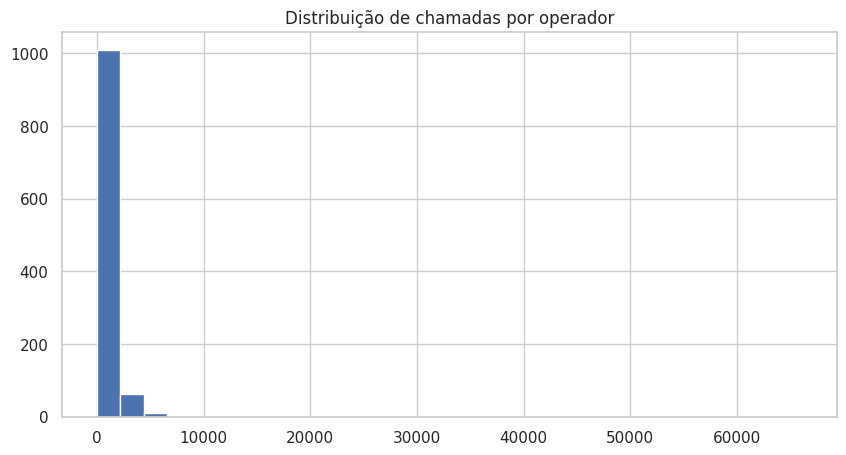

In [33]:
calls_per_operator = df_calls.groupby('operator_id')['calls_count'].sum()

plt.figure(figsize=(10,5))
calls_per_operator.hist(bins=30)
plt.title("Distribuição de chamadas por operador")
plt.show()

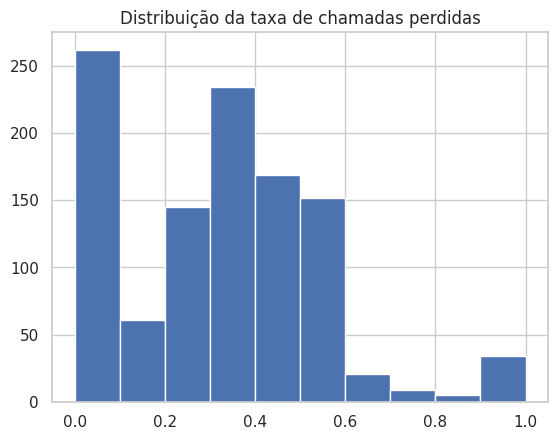

In [34]:
missed_rate = df_calls.groupby('operator_id')['missed'].mean()

missed_rate.hist()
plt.title("Distribuição da taxa de chamadas perdidas")
plt.show()

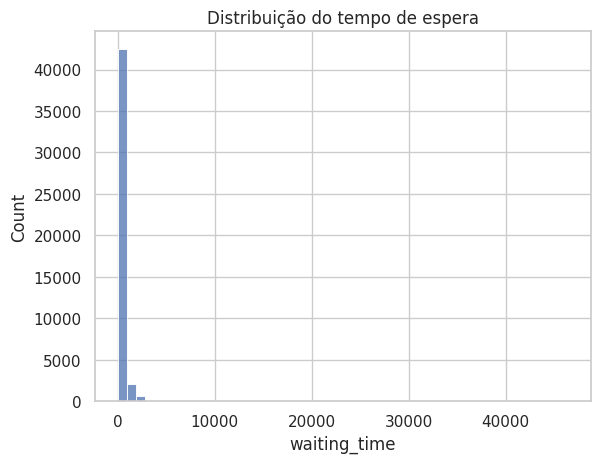

In [35]:
sns.histplot(df_calls['waiting_time'], bins=50)
plt.title("Distribuição do tempo de espera")
plt.show()

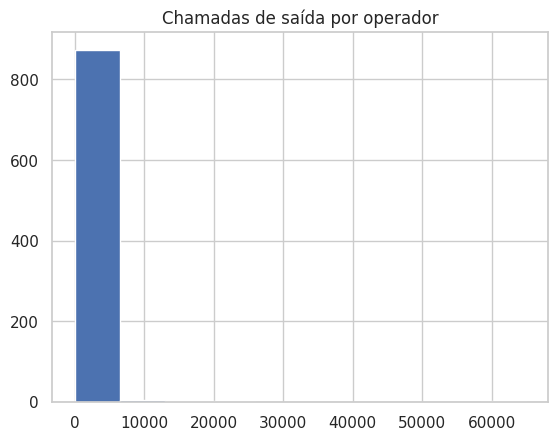

In [36]:
outgoing_calls = df_calls[df_calls['is_outgoing']]

outgoing_per_operator = outgoing_calls.groupby('operator_id')['calls_count'].sum()

outgoing_per_operator.hist()
plt.title("Chamadas de saída por operador")
plt.show()

# CRITÉRIO DE INEFICIÊNCIA

In [37]:
operator_metrics = df_calls.groupby('operator_id').agg({

    'waiting_time': 'mean',
    'missed': 'mean',
    'calls_count': 'sum'

}).reset_index()

In [40]:
missed_threshold = operator_metrics['missed'].quantile(0.75)
waiting_threshold = operator_metrics['waiting_time'].mean()
calls_threshold = operator_metrics['calls_count'].median()

In [41]:
operator_metrics['inefficient'] = (

    (operator_metrics['missed'] > missed_threshold) &
    (operator_metrics['waiting_time'] > waiting_threshold) &
    (operator_metrics['calls_count'] < calls_threshold)

)

# TESTE ESTATÍSTICO

In [44]:
stats.shapiro(operator_metrics['waiting_time'])

ShapiroResult(statistic=np.float64(0.4195359625018451), pvalue=np.float64(2.5981587085168926e-50))

In [49]:
inefficient = operator_metrics[operator_metrics['inefficient']]
efficient = operator_metrics[~operator_metrics['inefficient']]

In [51]:
stats.mannwhitneyu(
    inefficient['waiting_time'],
    efficient['waiting_time']
)

MannwhitneyuResult(statistic=np.float64(3801.0), pvalue=np.float64(0.009873763760391976))

In [52]:
print("Operadores ineficientes:", operator_metrics['inefficient'].sum())

Operadores ineficientes: 4
